# Exploratory Data Analysis (EDA) Penyakit Kardiovaskular

## Pendahuluan

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik data pasien serta pola awal yang berkaitan dengan risiko penyakit kardiovaskular. Pada notebook ini, analisis difokuskan pada hubungan antara beberapa indikator kesehatan utama dengan variabel target `cardio`.



## Tujuan Analisis

Analisis ini bertujuan untuk:
- mengidentifikasi gambaran umum dataset yang digunakan;
- memeriksa kondisi awal data, termasuk tipe data, missing values, dan statistik deskriptif;
- mengevaluasi hubungan usia, BMI, tekanan darah, dan kolesterol terhadap risiko penyakit kardiovaskular;
- mengidentifikasi fitur yang paling berkaitan dengan variabel target `cardio`.

## Persiapan Analisis


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11


## Memuat Dataset

Dataset yang digunakan merupakan data yang telah melalui tahap pembersihan awal dan disimpan dalam berkas `cardio_cleaned.csv`. Langkah berikut menampilkan beberapa baris pertama sebagai verifikasi struktur data.


In [3]:
df = pd.read_csv('../../data/processed/cardio_cleaned.csv')
df.head()


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,bmi,cardio
0,2,168,62.0,110,80,1,1,0,0,1,50,21.97,0
1,1,156,85.0,140,90,3,1,0,0,1,55,34.93,1
2,1,165,64.0,130,70,3,1,0,0,0,52,23.51,1
3,2,169,82.0,150,100,1,1,0,0,1,48,28.71,1
4,1,156,56.0,100,60,1,1,0,0,0,48,23.01,0


## Gambaran Umum Dataset

Bagian ini digunakan untuk memahami jumlah observasi, jumlah variabel, dan tipe data setiap fitur sebelum analisis visual dilakukan.


In [4]:
print(f"Jumlah baris dan kolom: {df.shape}")
print("\nTipe data setiap variabel:")
print(df.dtypes)


Jumlah baris dan kolom: (68540, 13)

Tipe data setiap variabel:
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
age_years        int64
bmi            float64
cardio           int64
dtype: object


## Pemeriksaan Kualitas Data

Pemeriksaan ini bertujuan memastikan tidak ada nilai hilang yang dapat mengganggu interpretasi visualisasi berikutnya.


In [5]:
df.isnull().sum().to_frame(name='jumlah_missing')


,jumlah_missing
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0
alco,0
active,0


## Statistik Deskriptif

Statistik deskriptif membantu memberikan konteks awal mengenai sebaran, kecenderungan pusat, dan rentang nilai dari setiap variabel numerik.


In [6]:
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
gender,68540.0,1.35,0.48,1.00,1.00,1.00,2.00,2.00
height,68540.0,164.44,7.84,130.00,159.00,165.00,170.00,207.00
weight,68540.0,74.12,14.28,35.00,65.00,72.00,82.00,200.00
ap_hi,68540.0,126.68,16.67,80.00,120.00,120.00,140.00,240.00
ap_lo,68540.0,81.32,9.40,50.00,80.00,80.00,90.00,150.00
cholesterol,68540.0,1.36,0.68,1.00,1.00,1.00,2.00,3.00
gluc,68540.0,1.23,0.57,1.00,1.00,1.00,1.00,3.00
smoke,68540.0,0.09,0.28,0.00,0.00,0.00,0.00,1.00
alco,68540.0,0.05,0.22,0.00,0.00,0.00,0.00,1.00
active,68540.0,0.80,0.40,0.00,1.00,1.00,1.00,1.00


## Pertanyaan Bisnis

Untuk menjaga analisis tetap terarah, EDA ini difokuskan pada pertanyaan-pertanyaan berikut:
- Bagaimana distribusi awal risiko penyakit kardiovaskular pada dataset?
- Apakah usia memengaruhi risiko penyakit kardiovaskular?
- Apakah tekanan darah berhubungan dengan risiko `cardio`?
- Apakah BMI memengaruhi risiko penyakit jantung?
- Bagaimana pengaruh kolesterol terhadap risiko `cardio`?
- Fitur apa yang paling berpengaruh terhadap penyakit kardiovaskular?


### Pertanyaan Bisnis 1

**Bagaimana distribusi awal risiko penyakit kardiovaskular pada dataset?**

Visualisasi berikut digunakan untuk melihat proporsi pasien dengan status `cardio = 0` dan `cardio = 1`. Informasi ini penting untuk memahami apakah data target cenderung seimbang atau tidak.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_16340\2486413317.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='cardio', order=[0, 1], palette=['#7AA6C2', '#D97B66'])


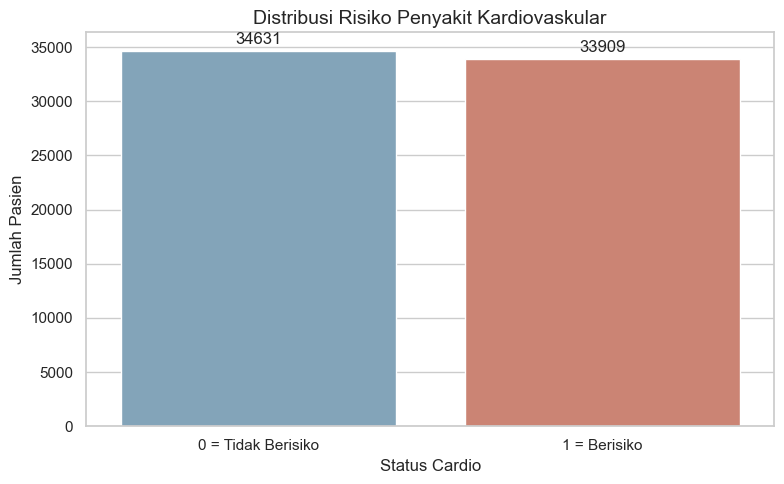

In [7]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='cardio', order=[0, 1], palette=['#7AA6C2', '#D97B66'])
ax.set_title('Distribusi Risiko Penyakit Kardiovaskular')
ax.set_xlabel('Status Cardio')
ax.set_ylabel('Jumlah Pasien')
ax.set_xticks([0, 1], labels=['0 = Tidak Berisiko', '1 = Berisiko'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.tight_layout()
plt.show()


### Interpretasi

Distribusi target terlihat relatif seimbang. Dari total 68.540 observasi, sekitar 49,47% pasien termasuk `cardio = 1`, sedangkan 50,53% lainnya berada pada kategori `cardio = 0`.

### Insight

Keseimbangan kelas ini menunjukkan bahwa data tidak mengalami ketimpangan target yang ekstrem. Oleh karena itu, perbandingan pola antar kelompok dapat dilakukan secara lebih proporsional pada tahap EDA.


### Pertanyaan Bisnis 2

**Apakah usia memengaruhi risiko penyakit kardiovaskular?**

Histogram berikut digunakan untuk membandingkan distribusi usia pasien antara kelompok dengan `cardio = 0` dan `cardio = 1`.


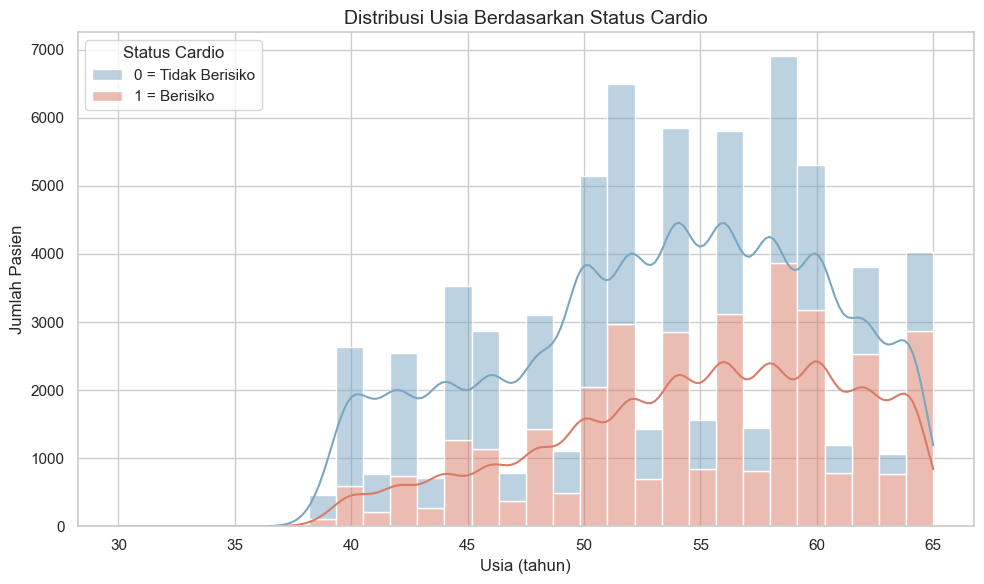

In [8]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=df,
    x='age_years',
    hue='cardio',
    hue_order=[0, 1],
    bins=30,
    kde=True,
    multiple='stack',
    palette=['#7AA6C2', '#D97B66']
)
ax.set_title('Distribusi Usia Berdasarkan Status Cardio')
ax.set_xlabel('Usia (tahun)')
ax.set_ylabel('Jumlah Pasien')
legend = ax.get_legend()
if legend is not None:
    legend.set_title('Status Cardio')
    legend.texts[0].set_text('0 = Tidak Berisiko')
    legend.texts[1].set_text('1 = Berisiko')
plt.tight_layout()
plt.show()


### Interpretasi

Distribusi menunjukkan bahwa kelompok pasien dengan `cardio = 1` cenderung berada pada rentang usia yang lebih tinggi. Rata-rata usia pada kelompok berisiko adalah 54,93 tahun, sedangkan kelompok tidak berisiko memiliki rata-rata 51,69 tahun.

### Insight

Usia tampak memiliki hubungan positif terhadap risiko penyakit kardiovaskular. Semakin tinggi usia pasien, semakin besar kecenderungan munculnya status `cardio` pada dataset ini.


### Pertanyaan Bisnis 3

**Apakah tekanan darah berhubungan dengan risiko `cardio`?**

Boxplot berikut membandingkan distribusi tekanan darah sistolik (`ap_hi`) pada dua kelompok pasien untuk melihat apakah terdapat perbedaan pola yang jelas.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_16340\4185428537.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='cardio', y='ap_hi', order=[0, 1], palette=['#7AA6C2', '#D97B66'])


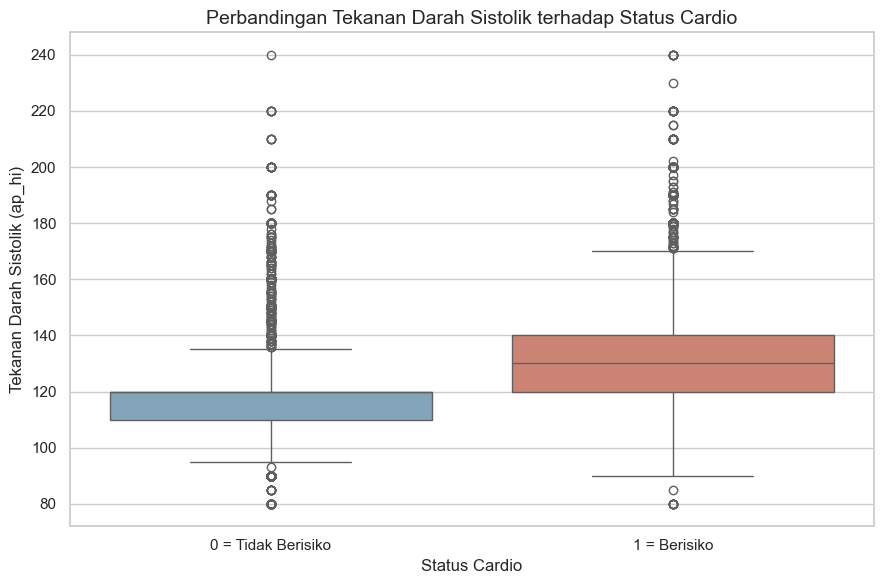

In [9]:
plt.figure(figsize=(9, 6))
ax = sns.boxplot(data=df, x='cardio', y='ap_hi', order=[0, 1], palette=['#7AA6C2', '#D97B66'])
ax.set_title('Perbandingan Tekanan Darah Sistolik terhadap Status Cardio')
ax.set_xlabel('Status Cardio')
ax.set_ylabel('Tekanan Darah Sistolik (ap_hi)')
ax.set_xticks([0, 1], labels=['0 = Tidak Berisiko', '1 = Berisiko'])
plt.tight_layout()
plt.show()


### Interpretasi

Kelompok `cardio = 1` memiliki median dan rata-rata tekanan darah sistolik yang lebih tinggi dibandingkan kelompok `cardio = 0`. Secara rata-rata, nilai `ap_hi` pada kelompok berisiko mencapai 133,89, sedangkan kelompok tidak berisiko berada pada 119,61.

### Insight

Tekanan darah sistolik merupakan indikator yang sangat kuat dalam membedakan risiko penyakit kardiovaskular pada data ini. Perbedaan distribusi yang jelas memperlihatkan bahwa kenaikan tekanan darah berkaitan dengan meningkatnya risiko `cardio`.


### Pertanyaan Bisnis 4

**Apakah BMI memengaruhi risiko penyakit jantung?**

Visualisasi berikut digunakan untuk membandingkan distribusi Body Mass Index (BMI) antara pasien dengan dan tanpa risiko penyakit kardiovaskular.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_16340\3591315311.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='cardio', y='bmi', order=[0, 1], palette=['#7AA6C2', '#D97B66'])


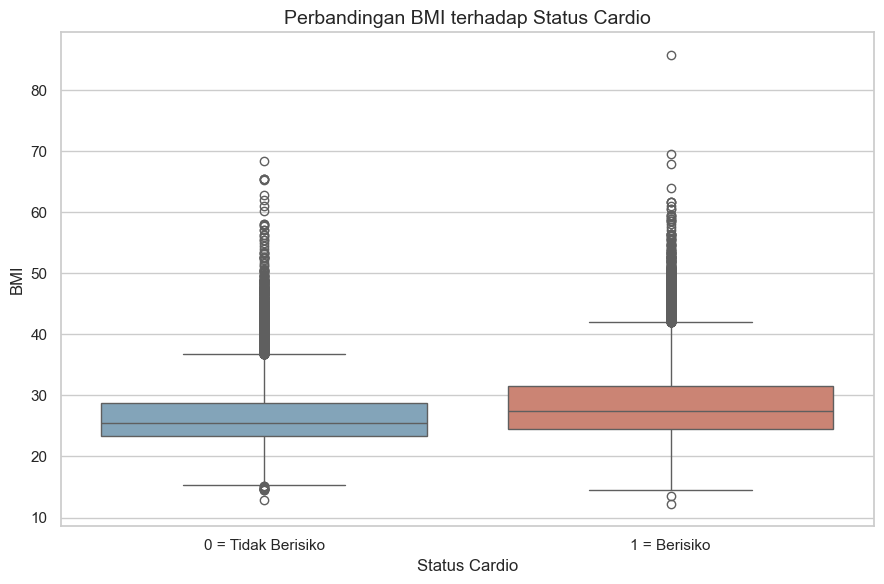

In [10]:
plt.figure(figsize=(9, 6))
ax = sns.boxplot(data=df, x='cardio', y='bmi', order=[0, 1], palette=['#7AA6C2', '#D97B66'])
ax.set_title('Perbandingan BMI terhadap Status Cardio')
ax.set_xlabel('Status Cardio')
ax.set_ylabel('BMI')
ax.set_xticks([0, 1], labels=['0 = Tidak Berisiko', '1 = Berisiko'])
plt.tight_layout()
plt.show()


### Interpretasi

Kelompok dengan `cardio = 1` menunjukkan nilai BMI yang cenderung lebih tinggi. Rata-rata BMI pada kelompok berisiko adalah 28,45, sedangkan pada kelompok tidak berisiko sebesar 26,46.

### Insight

BMI yang lebih tinggi tampak berkaitan dengan peningkatan risiko penyakit kardiovaskular. Temuan ini menunjukkan bahwa faktor berat badan dan komposisi tubuh perlu diperhatikan sebagai bagian dari evaluasi risiko.


### Pertanyaan Bisnis 5

**Bagaimana pengaruh kolesterol terhadap risiko `cardio`?**

Countplot berikut digunakan untuk melihat perubahan distribusi status `cardio` pada setiap kategori kolesterol.


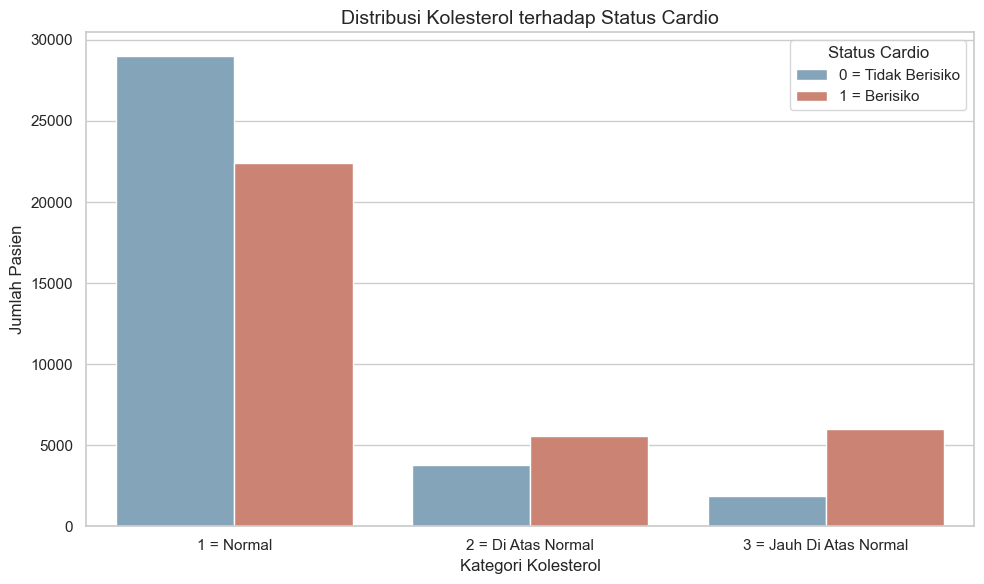

In [11]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df,
    x='cholesterol',
    hue='cardio',
    hue_order=[0, 1],
    palette=['#7AA6C2', '#D97B66']
)
ax.set_title('Distribusi Kolesterol terhadap Status Cardio')
ax.set_xlabel('Kategori Kolesterol')
ax.set_ylabel('Jumlah Pasien')
ax.set_xticks(
    [0, 1, 2],
    labels=['1 = Normal', '2 = Di Atas Normal', '3 = Jauh Di Atas Normal']
)
legend = ax.get_legend()
if legend is not None:
    legend.set_title('Status Cardio')
    legend.texts[0].set_text('0 = Tidak Berisiko')
    legend.texts[1].set_text('1 = Berisiko')
plt.tight_layout()
plt.show()


### Interpretasi

Proporsi pasien dengan `cardio = 1` meningkat seiring kenaikan kategori kolesterol. Pada kolesterol normal, proporsi `cardio = 1` sebesar 43,54%; pada kategori di atas normal meningkat menjadi 59,65%; dan pada kategori jauh di atas normal mencapai 76,24%.

### Insight

Kolesterol menunjukkan hubungan positif yang sangat jelas terhadap risiko penyakit kardiovaskular. Semakin tinggi kategori kolesterol pasien, semakin besar kemungkinan pasien termasuk ke dalam kelompok berisiko.


### Pertanyaan Bisnis 6

**Fitur apa yang paling berpengaruh terhadap penyakit kardiovaskular?**

Visualisasi pertama menampilkan heatmap korelasi antarvariabel. Tujuannya adalah memperoleh gambaran umum mengenai arah dan kekuatan hubungan antar fitur numerik, termasuk kaitannya dengan variabel target `cardio`.


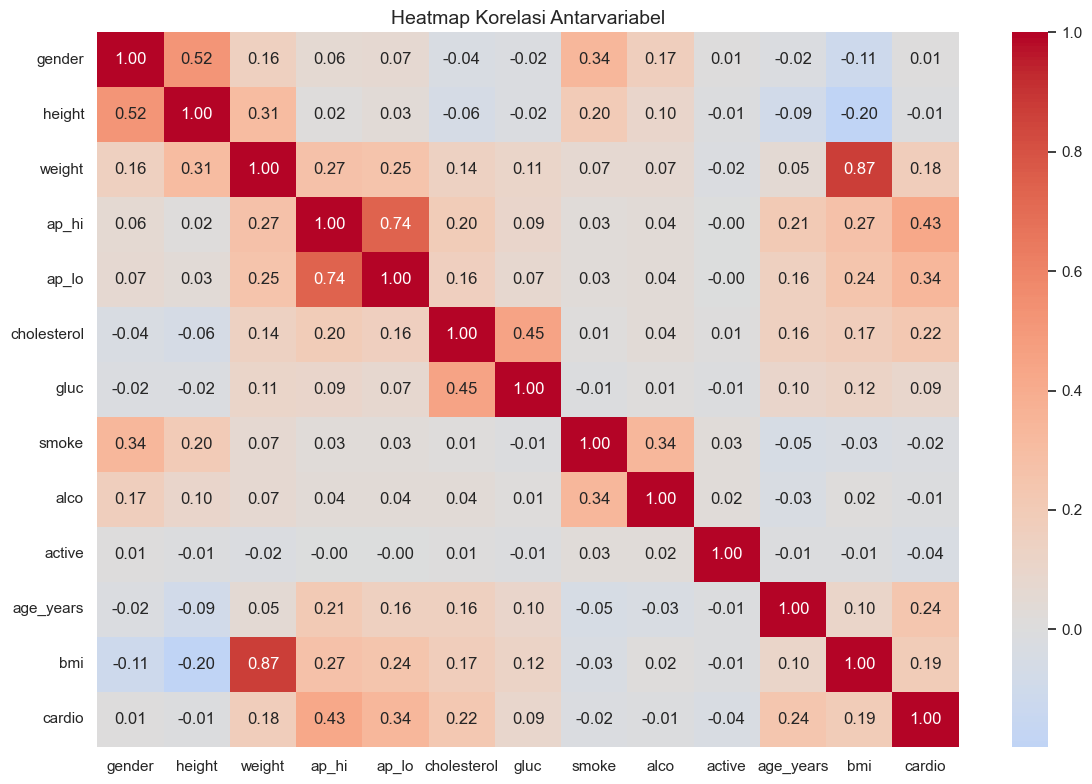

In [12]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Heatmap Korelasi Antarvariabel')
plt.tight_layout()
plt.show()


### Interpretasi

Heatmap menunjukkan bahwa variabel `cardio` memiliki korelasi positif yang paling menonjol dengan `ap_hi`, `ap_lo`, `age_years`, `cholesterol`, dan `bmi`. Sebaliknya, variabel seperti `active`, `smoke`, dan `height` memiliki hubungan yang lemah dan cenderung negatif.

### Insight

Secara umum, faktor tekanan darah, usia, dan indikator metabolik tampak lebih dominan dibandingkan variabel perilaku yang terekam secara biner pada dataset ini. Namun, hasil korelasi tetap perlu dibaca sebagai hubungan statistik, bukan hubungan kausal langsung.


### Pendalaman Pertanyaan Bisnis 6

Visualisasi berikut menyusun nilai korelasi fitur terhadap `cardio` dari yang paling kuat hingga yang paling lemah agar faktor yang paling relevan dapat diidentifikasi dengan lebih jelas.


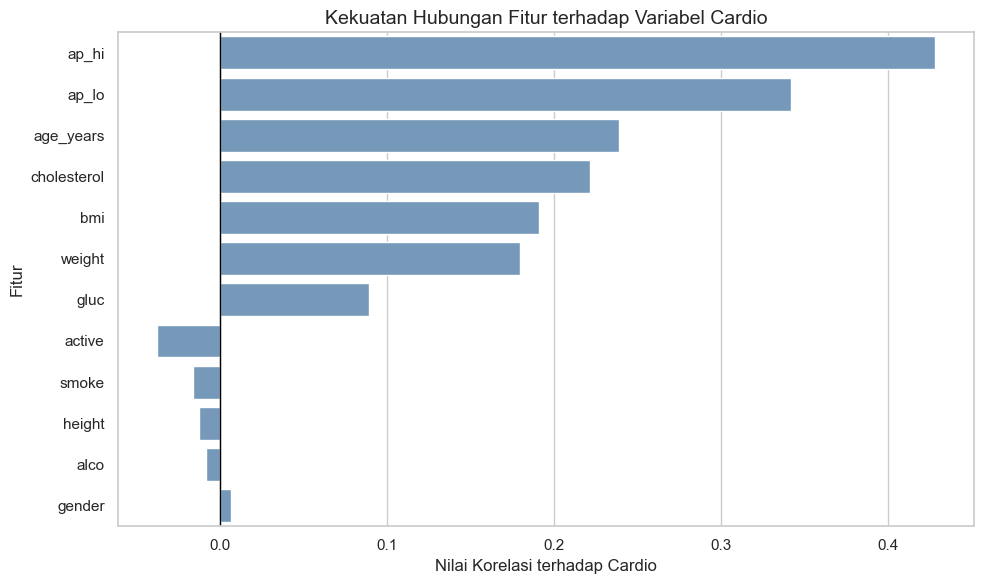

,korelasi_dengan_cardio
ap_hi,0.4281
ap_lo,0.3419
age_years,0.2390
cholesterol,0.2214
bmi,0.1913
weight,0.1800
gluc,0.0895
active,-0.0376
smoke,-0.0162
height,-0.0125


In [13]:
corr_cardio = (
    df.corr(numeric_only=True)['cardio']
    .drop('cardio')
    .sort_values(key=lambda series: series.abs(), ascending=False)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=corr_cardio.values, y=corr_cardio.index, color='#6B9AC4')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Kekuatan Hubungan Fitur terhadap Variabel Cardio')
ax.set_xlabel('Nilai Korelasi terhadap Cardio')
ax.set_ylabel('Fitur')
plt.tight_layout()
plt.show()

corr_cardio.round(4).to_frame(name='korelasi_dengan_cardio')


### Interpretasi

Urutan korelasi menunjukkan bahwa `ap_hi` (0,4281), `ap_lo` (0,3419), `age_years` (0,2390), `cholesterol` (0,2214), dan `bmi` (0,1913) merupakan fitur yang paling berkaitan dengan `cardio` pada dataset ini.

### Insight

Temuan ini mengindikasikan bahwa tekanan darah, usia, dan profil metabolik merupakan faktor utama yang perlu diperhatikan dalam risiko kardiovaskular. Variabel seperti `active`, `smoke`, dan `alco` tetap relevan secara klinis, tetapi pada dataset ini hubungan linearnya terhadap target relatif lebih lemah.


## Kesimpulan Akhir EDA

Berdasarkan hasil eksplorasi data, dapat disimpulkan bahwa:
- distribusi target `cardio` pada dataset relatif seimbang sehingga analisis komparatif antar kelompok dapat dilakukan dengan baik;
- pasien dengan risiko penyakit kardiovaskular cenderung lebih tua, memiliki BMI lebih tinggi, dan menunjukkan tekanan darah sistolik yang lebih tinggi;
- peningkatan kategori kolesterol diikuti oleh peningkatan proporsi pasien dengan `cardio = 1` secara konsisten;
- fitur yang paling berkaitan dengan risiko kardiovaskular pada dataset ini adalah `ap_hi`, `ap_lo`, `age_years`, `cholesterol`, dan `bmi`.

Secara keseluruhan, EDA ini menunjukkan bahwa indikator tekanan darah, usia, dan kondisi metabolik merupakan sinyal utama dalam memahami risiko penyakit kardiovaskular pada data pasien yang dianalisis.
